In [29]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score, accuracy_score
from lib.PraNet_Res2Net import PraNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_DIR = 'c:/Users/Dara/PraNet/Images'
MASK_DIR = 'c:/Users/Dara/PraNet/Masks'
MODEL_PATH = 'pretrained_weights.pth'

THRESHOLD = 0.5

class PolypDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (352, 352))
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (352, 352), interpolation=cv2.INTER_NEAREST)
        mask = (mask == 255).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask, self.images[idx]


def compute_mae(pred_mask, true_mask):
    return np.mean(np.abs(pred_mask - true_mask))

def compute_s_measure(pred_mask, true_mask):
    pred_img = (pred_mask * 255).astype(np.uint8)
    true_img = (true_mask * 255).astype(np.uint8)
    return ssim(pred_img, true_img, data_range=255)

def compute_e_measure(pred_mask, true_mask):

    epsilon = 1e-8
    thresholds = np.linspace(0, 1, 256)
    max_e_score = 0

    for threshold in thresholds:
        binary_pred = (pred_mask >= threshold).astype(np.float32)
        centered_pred = binary_pred - binary_pred.mean()
        centered_true = true_mask - true_mask.mean()

        alignment_matrix = (2 * centered_pred * centered_true) / \
                           (centered_pred**2 + centered_true**2 + epsilon)

        enhanced_matrix = ((alignment_matrix + 1) ** 2) / 4
        e_score = np.mean(enhanced_matrix)
        max_e_score = max(max_e_score, e_score)

    return max_e_score


def evaluate_model(model, dataloader, device, threshold=0.5):
    model.to(device)
    model.eval()

    y_true_pixels = []
    y_pred_pixels = []
    all_mae, all_s, all_e = [], [], []

    with torch.no_grad():
        for images, masks, filenames in tqdm(dataloader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)[0]
            probs = torch.sigmoid(outputs).cpu().numpy()
            masks = masks.cpu().numpy()

            for i in range(images.shape[0]):
                pred_prob = probs[i].squeeze()
                pred_bin = (pred_prob > threshold).astype(np.uint8)
                true_mask = masks[i].squeeze()

                y_true_pixels.extend(true_mask.flatten())
                y_pred_pixels.extend(pred_bin.flatten())

                all_mae.append(compute_mae(pred_prob, true_mask))
                all_s.append(compute_s_measure(pred_prob, true_mask))
                all_e.append(compute_e_measure(pred_prob, true_mask))


    y_true_np = np.array(y_true_pixels)
    y_pred_np = np.array(y_pred_pixels)

    dice = (2. * np.sum(y_true_np * y_pred_np)) / (np.sum(y_true_np) + np.sum(y_pred_np) + 1e-8)
    miou = jaccard_score(y_true_np, y_pred_np)


    print(f"Dice:     {dice:.4f}")
    print(f"mIoU:        {miou:.4f}")
    print(f"Average MAE:     {np.mean(all_mae) :.4f}")
    print(f"S-Measure:       {np.mean(all_s):.4f}")
    print(f"max E-Measure:   {np.max(all_e):.4f}")



dataset = PolypDataset(IMAGE_DIR, MASK_DIR)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

model = PraNet()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
evaluate_model(model, dataloader, device)


100%|██████████| 196/196 [01:22<00:00,  2.36it/s]


Dice:     0.6200
mIoU:        0.5625
Average MAE:     0.0305
S-Measure:       0.7387
max E-Measure:   0.8593


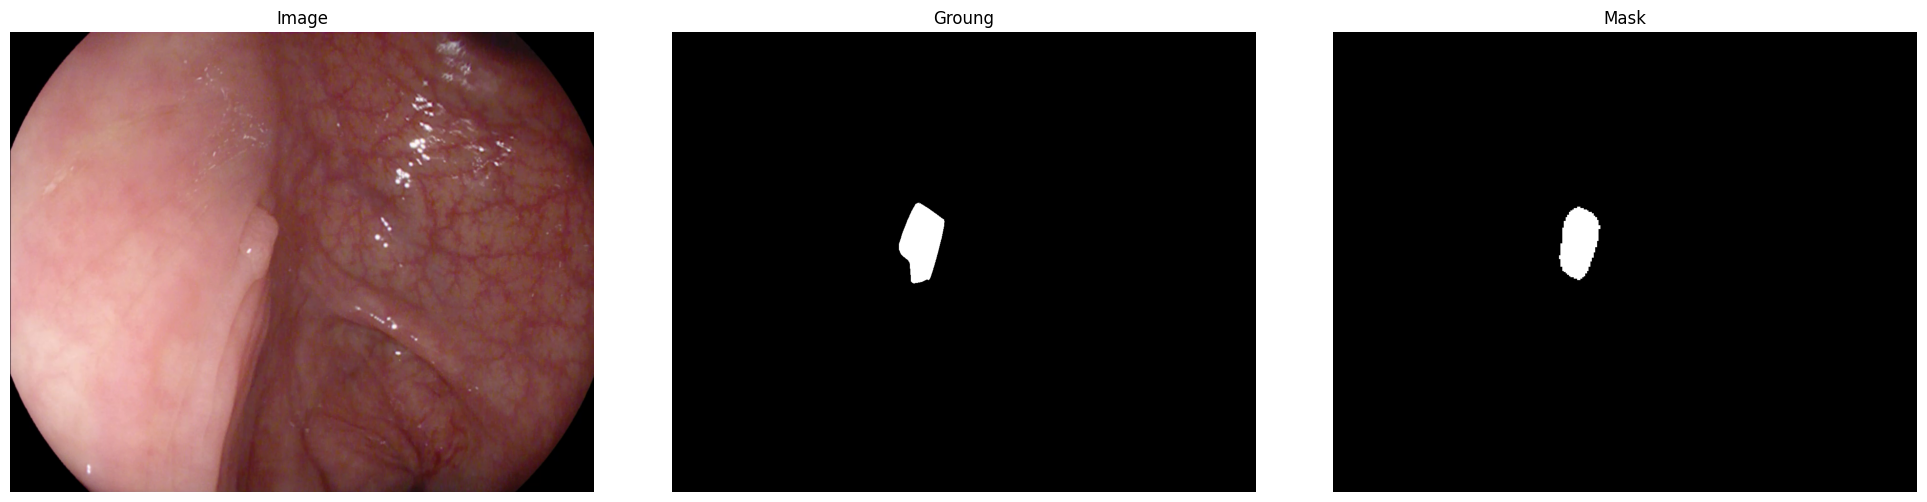

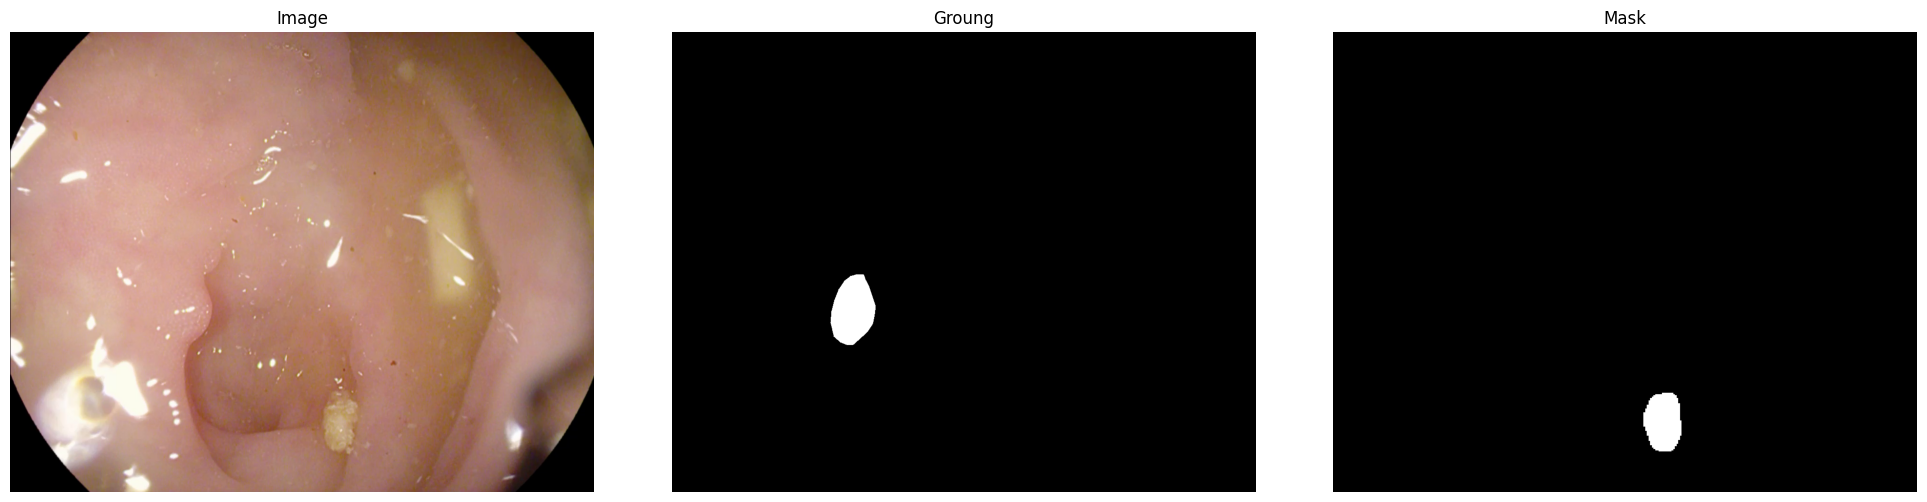

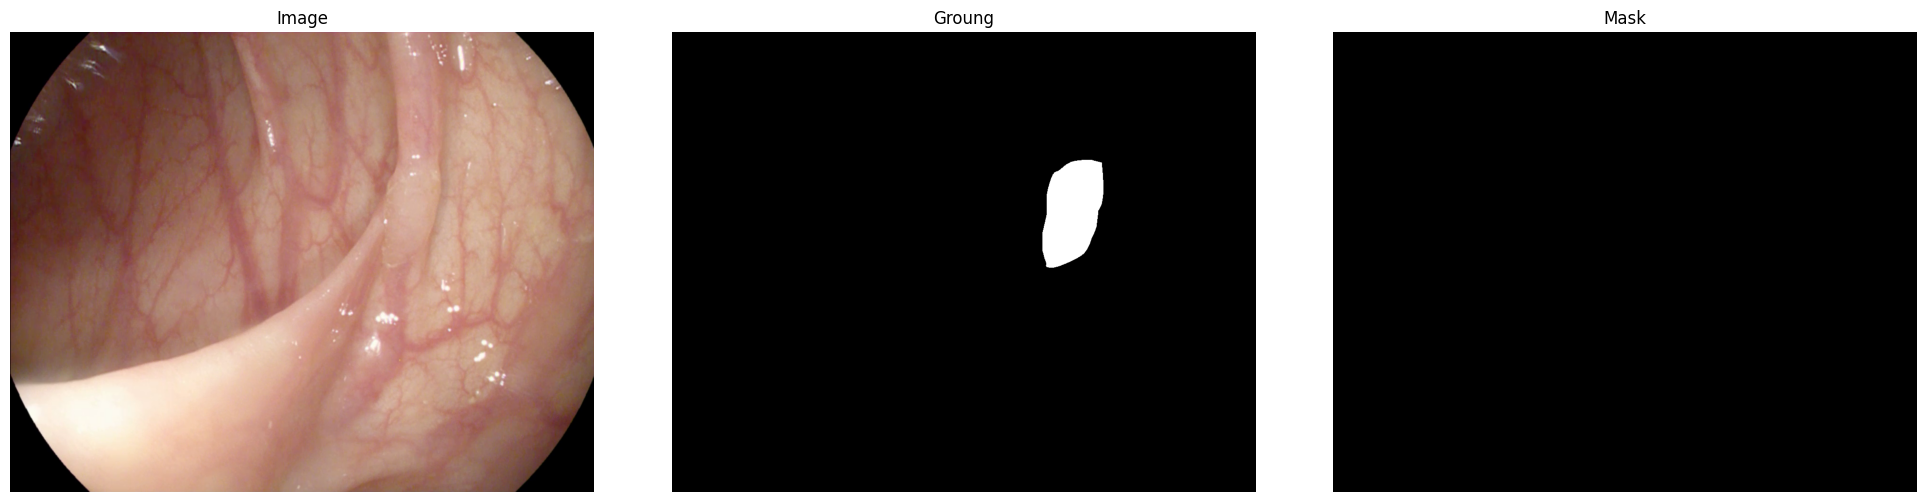

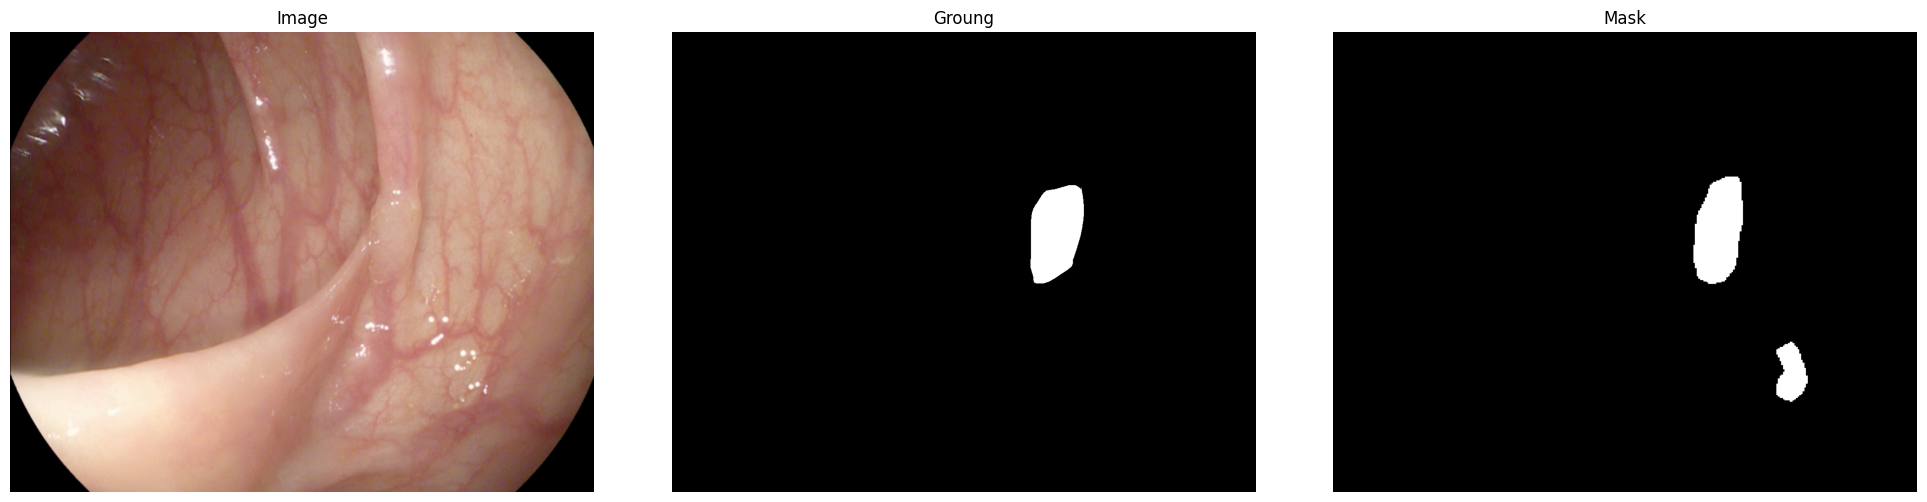

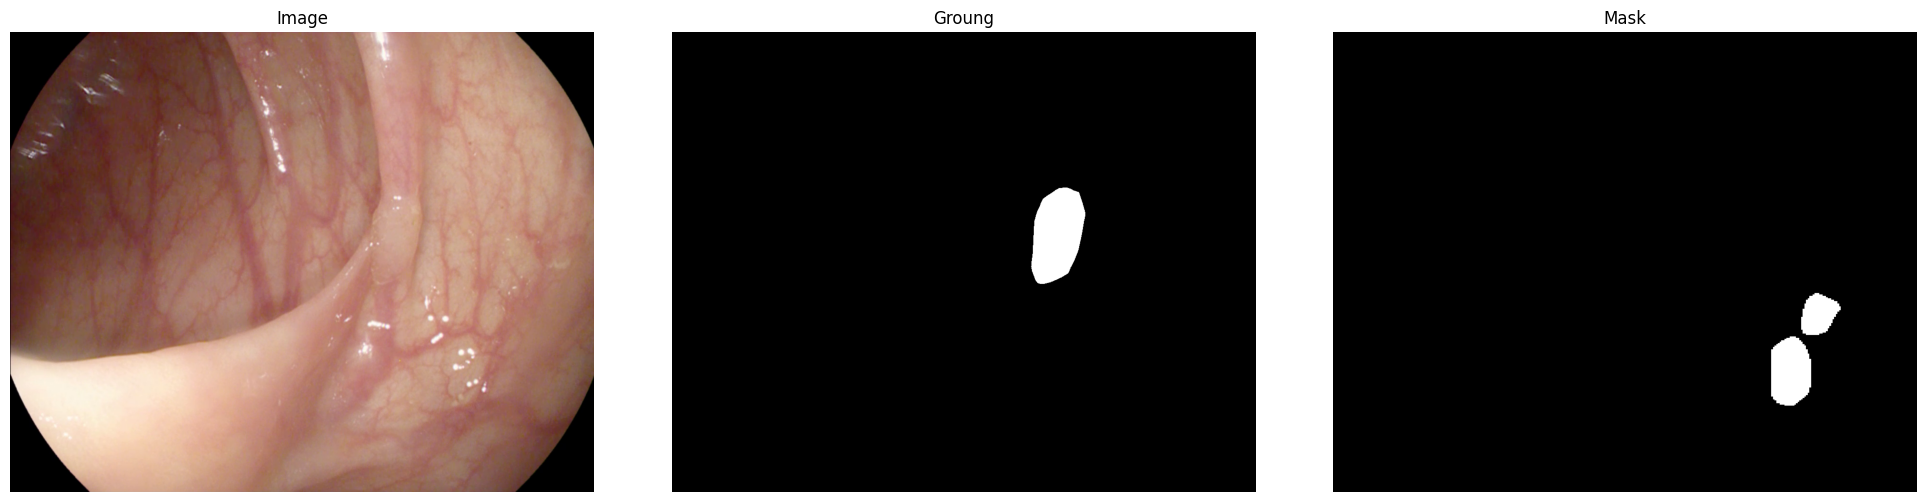

In [34]:
import matplotlib.pyplot as plt
image_files = sorted(os.listdir(IMAGE_DIR))
OUTPUT_DIR_PRANET = 'C:/Users/Dara/PraNet/pranet_results_EITS'
for image_name in image_files[:5]:
    image_path = os.path.join(IMAGE_DIR, image_name)
    mask_path = os.path.join(MASK_DIR, image_name)
    pranet_mask_path = os.path.join(OUTPUT_DIR_PRANET, image_name)
    # unet_mask_path = os.path.join(OUTPUT_DIR_UNET, image_name)

    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    ideal_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    pranet_mask = cv2.imread(pranet_mask_path, cv2.IMREAD_GRAYSCALE)
    # unet_mask = cv2.imread(unet_mask_path, cv2.IMREAD_GRAYSCALE)


    height, width = ideal_mask.shape
    pranet_mask_resized = cv2.resize(pranet_mask, (width, height), interpolation=cv2.INTER_NEAREST)
    # unet_mask_resized = cv2.resize(unet_mask, (width, height), interpolation=cv2.INTER_NEAREST)

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    axs[0].imshow(image)
    axs[0].set_title('Image')
    axs[0].axis('off')

    axs[1].imshow(ideal_mask, cmap='gray')
    axs[1].set_title('Groung')
    axs[1].axis('off')

    axs[2].imshow(pranet_mask_resized, cmap='gray')
    axs[2].set_title('Mask')
    axs[2].axis('off')
    
    # axs[3].imshow(unet_mask_resized, cmap='gray')
    # axs[3].set_title('UNet')
    # axs[3].axis('off')

    plt.tight_layout()
    plt.show()
